# Лабораторная работа 5
## Слесарев Никита ФИТ-231

(15 баллов)


№1 (2 балла)

Выполните задания из файла https://cloud.mail.ru/public/qDbR/69k4MLzjg. 

In [12]:
# Практическое занятие 1: Элементы описательной статистики

# 1. Импорты
import math
import statistics
import numpy as np
import scipy.stats
import pandas as pd

# 2. Исходные списки
x = [10.0, 2, 2.5, 5, 26.0]
x_with_nan = [10.0, 2, 2.5, math.nan, 5, 26.0]
print(f'Вывод исходных данных, которые содержатся в x: {x}')
print(f'Вывод исходных данных, которые содержатся в x_with_nan: {x_with_nan}')

# 3. Преобразование в массивы NumPy и Series Pandas
y, y_with_nan = np.array(x), np.array(x_with_nan)
z, z_with_nan = pd.Series(x), pd.Series(x_with_nan)
print(f'Вывод данных, которые содержатся в y и y_with_nan: {y}, {y_with_nan}')
print(f'Вывод данных, которые содержатся в z и z_with_nan:\n{z}\n{z_with_nan}')

# 4. Среднее арифметическое
mean_1 = sum(x) / len(x)
print(f'Расчет среднего значения, используя sum и len: {mean_1}')

mean_2 = statistics.mean(x)
print(f'Расчет среднего значения, используя statistics.mean(x): {mean_2}')

# fmean доступен в Python 3.8+
try:
    mean_3 = statistics.fmean(x)
    print(f'Расчет среднего значения, используя statistics.fmean(x): {mean_3}')
except AttributeError:
    print('statistics.fmean недоступна в вашей версии Python')

mean_4 = statistics.mean(x_with_nan)
print(f'Расчет среднего значения с nan (statistics.mean): {mean_4}')

mean_5 = np.mean(y)
print(f'Расчет среднего значения, используя NumPy: {mean_5}')

mean_6 = np.nanmean(y_with_nan)
print(f'Расчет среднего значения с помощью NumPy, игнорируя nan: {mean_6}')

mean_7 = z.mean()
print(f'Расчет среднего значения объекта pd.Series: {mean_7}')

# 5. Средневзвешенное значение
x = [6.0, 1, 2.5, 6, 25.0]
w = [0.1, 0.2, 0.3, 0.25, 0.15]
wmean = sum(w[i] * x[i] for i in range(len(x))) / sum(w)
print(f'Расчет средневзвешанного с помощью range: {wmean}')

wmean2 = sum(x_ * w_ for (x_, w_) in zip(x, w)) / sum(w)
print(f'Расчет средневзвешанного с помощью zip: {wmean2}')

y, z, w = np.array(x), pd.Series(x), np.array(w)
wmean3 = np.average(y, weights=w)
print(f'Расчет средневзвешанного с помощью np.average: {wmean3}')

o = (w * y).sum() / w.sum()
print(f'Расчет средневзвешанного поэлементным умножением: {o}')

# Восстановим x_with_nan для дальнейших шагов
x_with_nan = [10.0, 2, 2.5, math.nan, 5, 26.0]
y_with_nan = np.array(x_with_nan)

w_nan = np.array([0.1, 0.2, 0.3, 0.0, 0.2, 0.1])
weighted_nan = (w_nan * y_with_nan).sum() / w_nan.sum()
print(f'Расчет средневзвешанного для набора с nan: {weighted_nan}')

# 6. Гармоническое среднее
hmean = len(x) / sum(1 / item for item in x if item != 0)
print(f'Расчет гармонического среднего: {hmean}')

hmean2 = statistics.harmonic_mean(x)
print(f'Расчет гармонического среднего (statistics.harmonic_mean): {hmean2}')

hmean_nan = statistics.harmonic_mean(x_with_nan)
print(f'Гармоническое среднее с nan: {hmean_nan}')

hmean_zero = statistics.harmonic_mean([1, 0, 2])
print(f'Гармоническое среднее с нулём: {hmean_zero}')

hmean_scipy = scipy.stats.hmean(y)
print(f'Гармоническое среднее (scipy.stats.hmean): {hmean_scipy}')

# 7. Среднее геометрическое
gmean = 1
for item in x:
    if item > 0:
        gmean *= item
    else:
        gmean = float('nan')
        break
if not math.isnan(gmean):
    gmean **= 1 / len([i for i in x if i > 0])
print(f'Вычисление геометрического среднего: {gmean}')

# statistics.geometric_mean доступен начиная с Python 3.8
try:
    gmean2 = statistics.geometric_mean(x)
    print(f'Геометрическое среднее (statistics.geometric_mean): {gmean2}')
except AttributeError:
    print('statistics.geometric_mean недоступна в вашей версии Python')

gmean_scipy = scipy.stats.gmean(y)
print(f'Геометрическое среднее (scipy.stats.gmean): {gmean_scipy}')

# 8. Медиана
n = len(x)
if n % 2:
    median_ = sorted(x)[n // 2]
else:
    x_ord = sorted(x)
    median_ = 0.5 * (x_ord[n//2 - 1] + x_ord[n//2])
print(f'Расчет медианы на чистом Python: {median_}')

median_2 = statistics.median(x)
print(f'Расчет медианы (statistics.median): {median_2}')

median_low = statistics.median_low(x[:-1])
print(f'Медиана_low: {median_low}')

median_high = statistics.median_high(x[:-1])
print(f'Медиана_high: {median_high}')

median_np = np.median(y)
print(f'Медиана (NumPy): {median_np}')

# 9. Мода
u = [2, 3, 2, 8, 12]
mode_ = max((u.count(item), item) for item in set(u))[1]
print(f'Вычисление моды на чистом Python: {mode_}')

mode_2 = statistics.mode(u)
print(f'Мода (statistics.mode): {mode_2}')

mode_scipy = scipy.stats.mode(u, keepdims=True)
print(f'Мода (scipy.stats.mode): mode={mode_scipy.mode[0]}, count={mode_scipy.count[0]}')

# 10. Дисперсия
x = [6.0, 1, 2.5, 6, 25.0]  # восстановим x
n = len(x)
mean = sum(x) / n
var_ = sum((item - mean)**2 for item in x) / (n - 1)
print(f'Оценка дисперсии на чистом Python: {var_}')

var_1 = statistics.variance(x)
print(f'Дисперсия (statistics.variance): {var_1}')

var_nan = statistics.variance(x_with_nan)
print(f'Дисперсия с nan: {var_nan}')

var_2 = np.var(y, ddof=1)
print(f'Дисперсия (np.var, ddof=1): {var_2}')

var_3 = y.var(ddof=1)
print(f'Дисперсия (метод .var): {var_3}')

# 11. Стандартное отклонение
std_ = var_ ** 0.5
print(f'Стандартное отклонение на чистом Python: {std_}')

std_2 = statistics.stdev(x)
print(f'Стандартное отклонение (statistics.stdev): {std_2}')

std_3 = np.std(y, ddof=1)
print(f'Стандартное отклонение (NumPy): {std_3}')

# 12. Смещение (асимметрия)
x = [8.0, 1, 2.5, 4, 28.0]
n = len(x)
mean_ = sum(x) / n
var_ = sum((item - mean_)**2 for item in x) / (n - 1)
std_ = var_ ** 0.5
if std_ > 0:
    skew_ = (sum((item - mean_)**3 for item in x) * n) / ((n - 1) * (n - 2) * std_**3)
    print(f'Смещение на чистом Python: {skew_}')
else:
    print('Смещение не определено (std = 0)')

z = pd.Series(x)
print(f'Смещение (Pandas): {z.skew()}')

# 13. Процентили
x = [-5.0, -1.1, 0.1, 2.0, 8.0, 12.8, 21.0, 25.8, 41.0]
y = np.array(x)
print(f'5-й процентиль (NumPy): {np.percentile(y, 5)}')
print(f'95-й процентиль (NumPy): {np.percentile(y, 95)}')

z = pd.Series(y)
print(f'5-й процентиль (Pandas .quantile): {z.quantile(0.05)}')

# 14. Диапазон
print(f'Диапазон (np.ptp): y={np.ptp(y)}, y_with_nan={np.ptp(y_with_nan)}, z_with_nan={np.ptp(z_with_nan)}')

# 15. Сводка описательной статистики
result = scipy.stats.describe(y, ddof=1, bias=False)
print(f'\nСводка (scipy.stats.describe):\n{result}')

result2 = pd.Series(y).describe()
print(f'\nСводка (Pandas .describe):\n{result2}')

Вывод исходных данных, которые содержатся в x: [10.0, 2, 2.5, 5, 26.0]
Вывод исходных данных, которые содержатся в x_with_nan: [10.0, 2, 2.5, nan, 5, 26.0]
Вывод данных, которые содержатся в y и y_with_nan: [10.   2.   2.5  5.  26. ], [10.   2.   2.5  nan  5.  26. ]
Вывод данных, которые содержатся в z и z_with_nan:
0    10.0
1     2.0
2     2.5
3     5.0
4    26.0
dtype: float64
0    10.0
1     2.0
2     2.5
3     NaN
4     5.0
5    26.0
dtype: float64
Расчет среднего значения, используя sum и len: 9.1
Расчет среднего значения, используя statistics.mean(x): 9.1
Расчет среднего значения, используя statistics.fmean(x): 9.1
Расчет среднего значения с nan (statistics.mean): nan
Расчет среднего значения, используя NumPy: 9.1
Расчет среднего значения с помощью NumPy, игнорируя nan: 9.1
Расчет среднего значения объекта pd.Series: 9.1
Расчет средневзвешанного с помощью range: 6.8
Расчет средневзвешанного с помощью zip: 6.8
Расчет средневзвешанного с помощью np.average: 6.8
Расчет средневзвеша

№2 (3 балла)
Выполните задания из файла https://cloud.mail.ru/public/JAFw/L4EF7Eyy7. Данные скачайте
отсюда https://cloud.mail.ru/public/bevg/K948tN4hd.

=== 1) Описание датасета ===
Количество строк: 1460
Количество столбцов (параметров): 81

Список всех параметров:
['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 

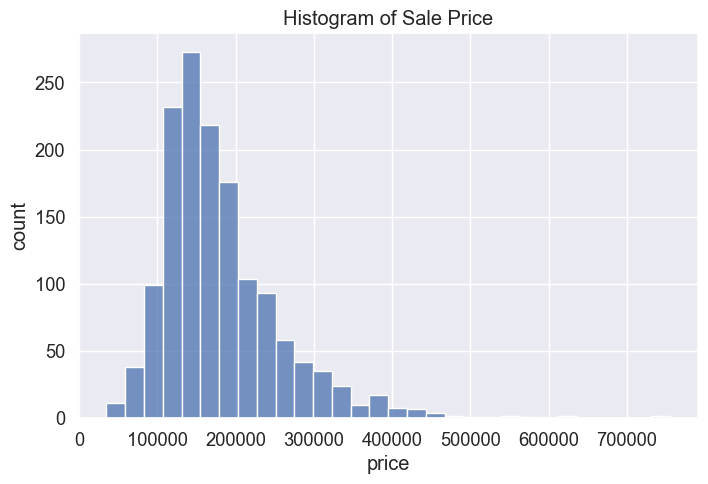

Skewness: 1.8829
Kurtosis: 6.5363

=== 6.2) Boxplot SalePrice ===


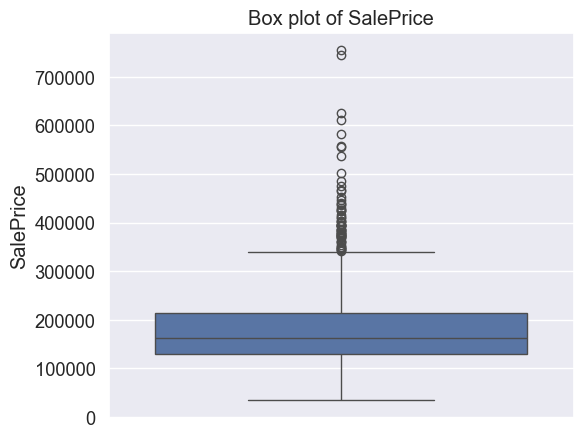


=== 6.3) Анализ по CentralAir ===


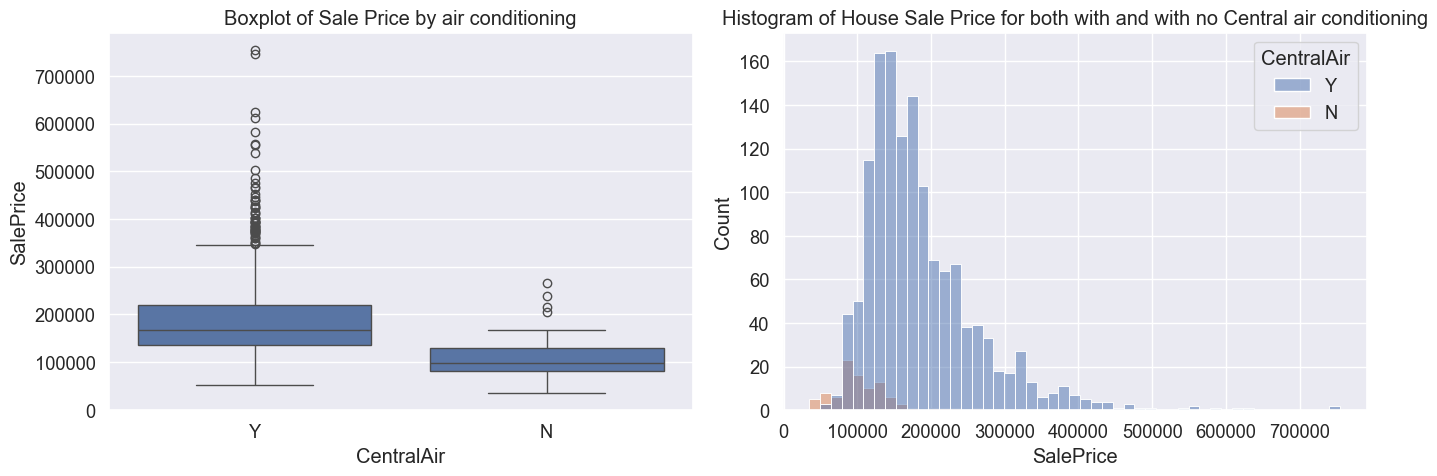


Описательная статистика по CentralAir:
             count           mean           std      min       25%       50%  \
CentralAir                                                                     
N             95.0  105264.073684  40671.273961  34900.0   82000.0   98000.0   
Y           1365.0  186186.709890  78805.206820  52000.0  134800.0  168000.0   

                 75%       max  
CentralAir                      
N           128500.0  265979.0  
Y           219210.0  755000.0  

=== Анализ по GarageCars ===


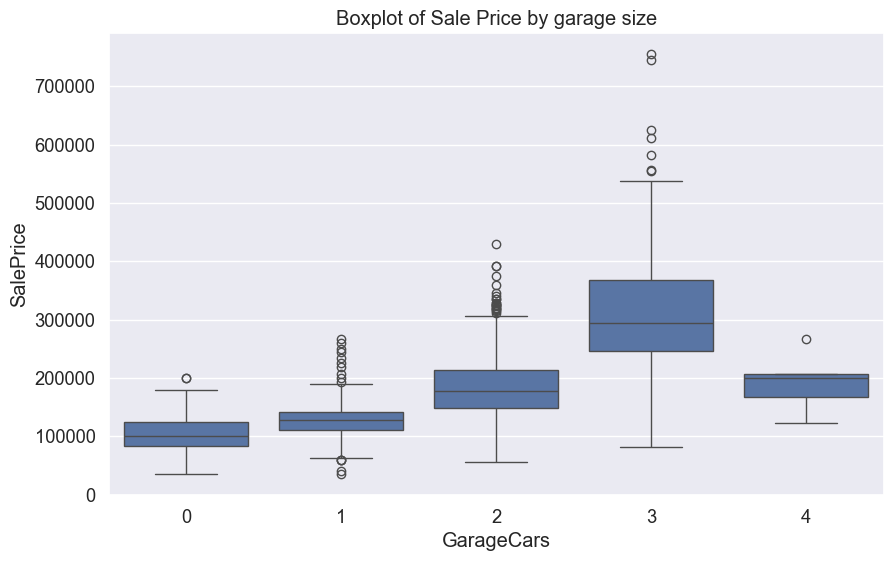

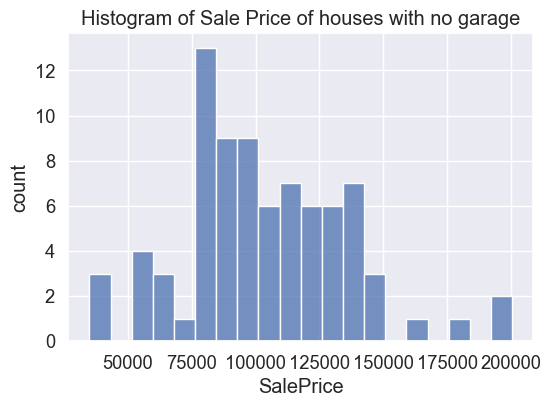

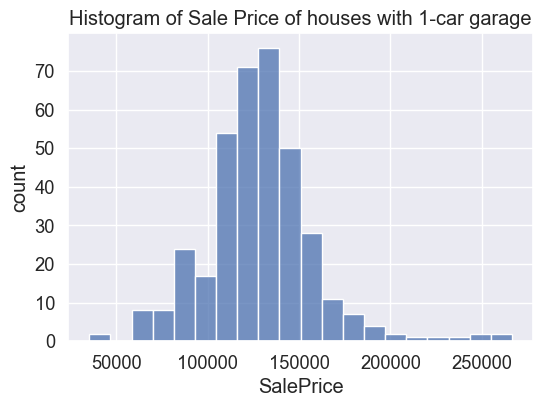

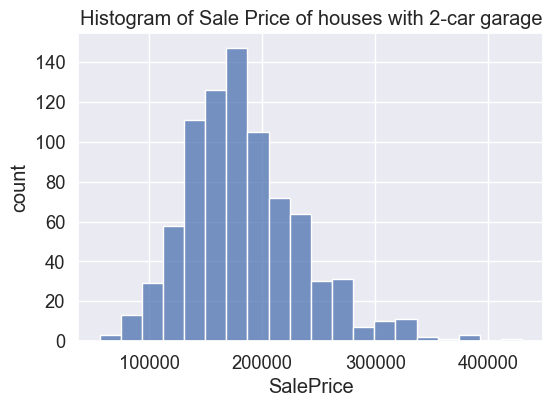

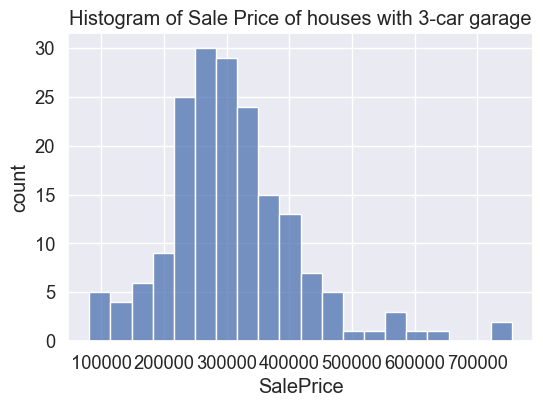

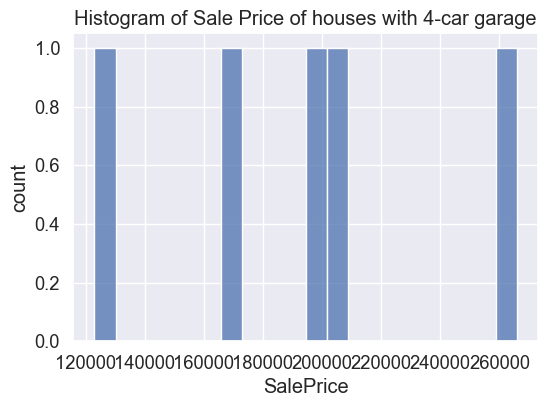


=== 6.4) Таблицы частот ===
Частота размеров гаража:
GarageCars
0    0.055479
1    0.252740
2    0.564384
3    0.123973
4    0.003425
Name: count, dtype: float64

Частота центрального кондиционирования:
CentralAir
Y    0.934932
N    0.065068
Name: count, dtype: float64

=== 6.5) Числовые характеристики ===
Доля домов с ценой между 25% и 75%: 0.5021
Доля домов с площадью подвала между 25% и 75%: 0.5000
Доля домов, удовлетворяющих хотя бы одному условию: 0.7144

IQR без кондиционера: 46500.0
IQR с кондиционером: 84410.0

=== 6.6) Стратификация по возрасту ===


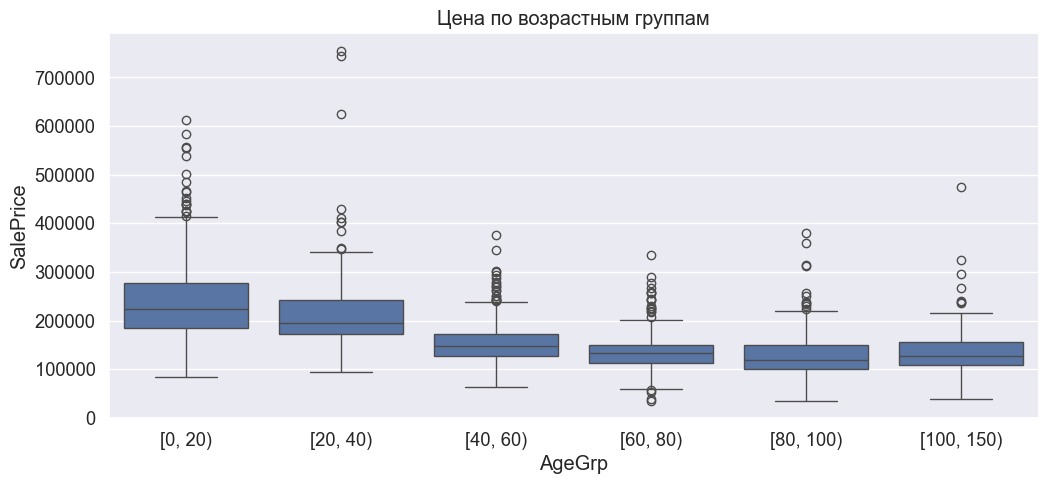

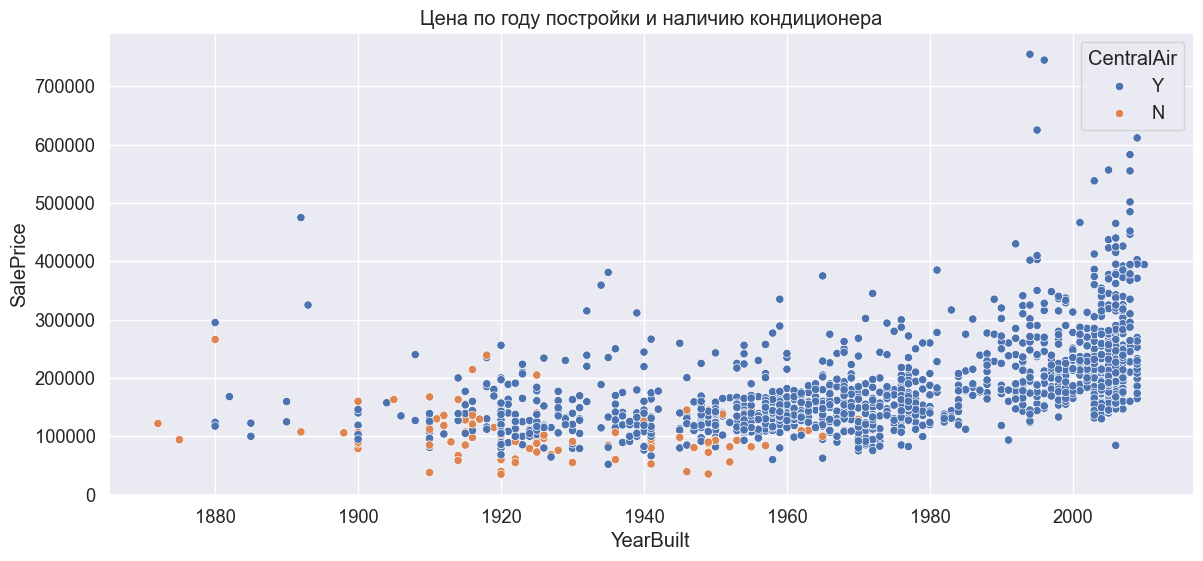


Доля типов домов по году и CentralAir (фрагмент):
BldgType                        1Fam  2fmCon  Duplex  Twnhs  TwnhsE
YearBuilt YearBuilt CentralAir                                     
2001      2001      Y          1.000     NaN     NaN    NaN   1.000
2002      2002      Y          1.000     NaN     NaN    NaN     NaN
2003      2003      Y          1.000     NaN     NaN  1.000   1.000
2004      2004      Y          1.000     NaN     NaN  1.000   1.000
2005      2005      Y          1.000     NaN     NaN  1.000   1.000
2006      2006      Y          1.000     NaN     NaN  1.000   1.000
2007      2007      Y          1.000     NaN     NaN  1.000   1.000
2008      2008      Y          1.000     NaN     NaN    NaN   1.000
2009      2009      Y          1.000     NaN     NaN    NaN   1.000
2010      2010      Y          1.000     NaN     NaN    NaN     NaN

=== 6.7) Диаграммы рассеяния ===


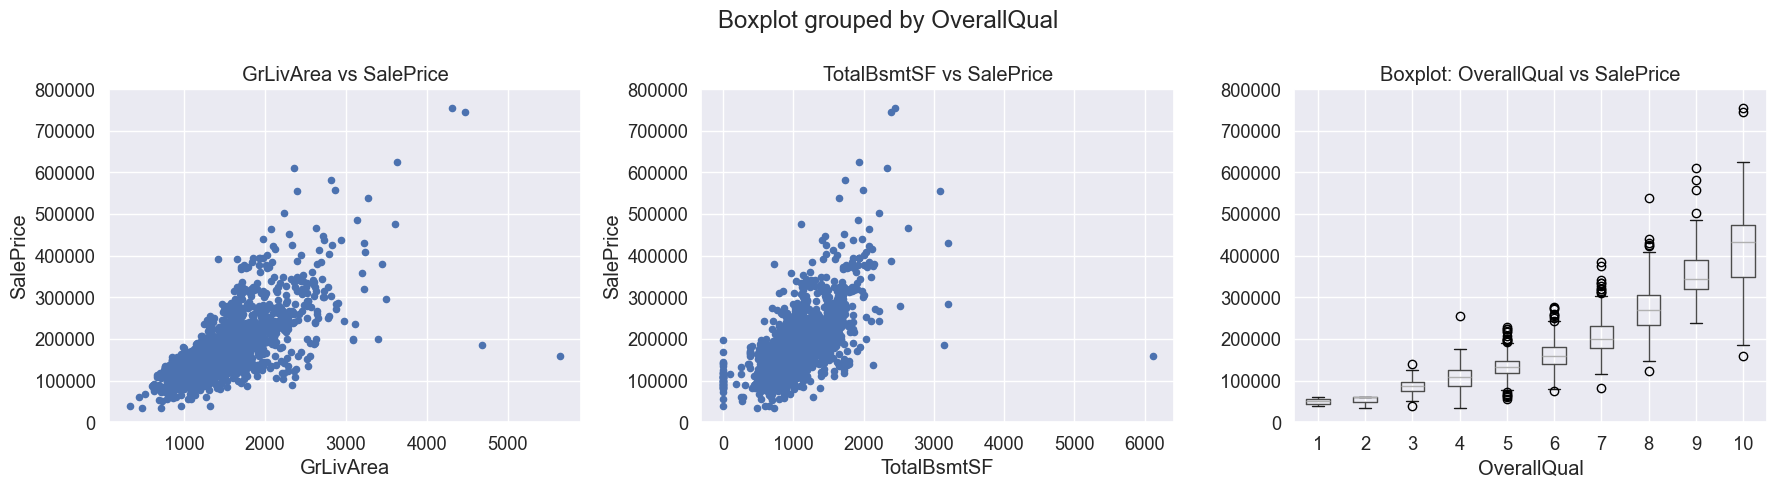

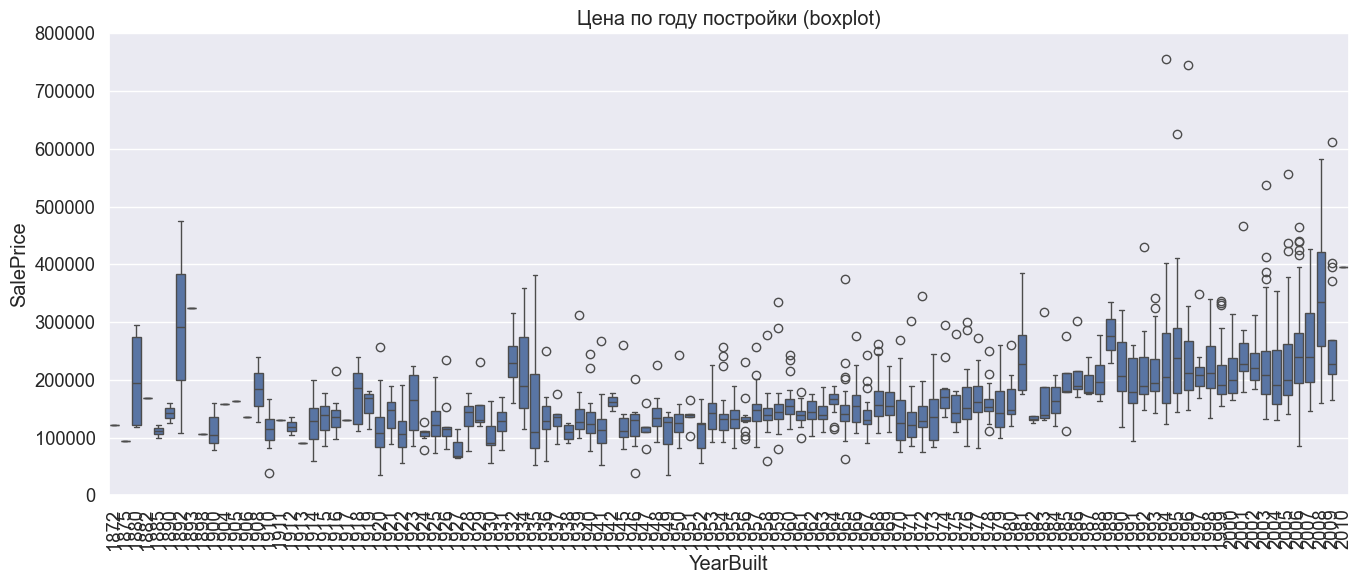


=== 6.8) Тепловая карта корреляций ===


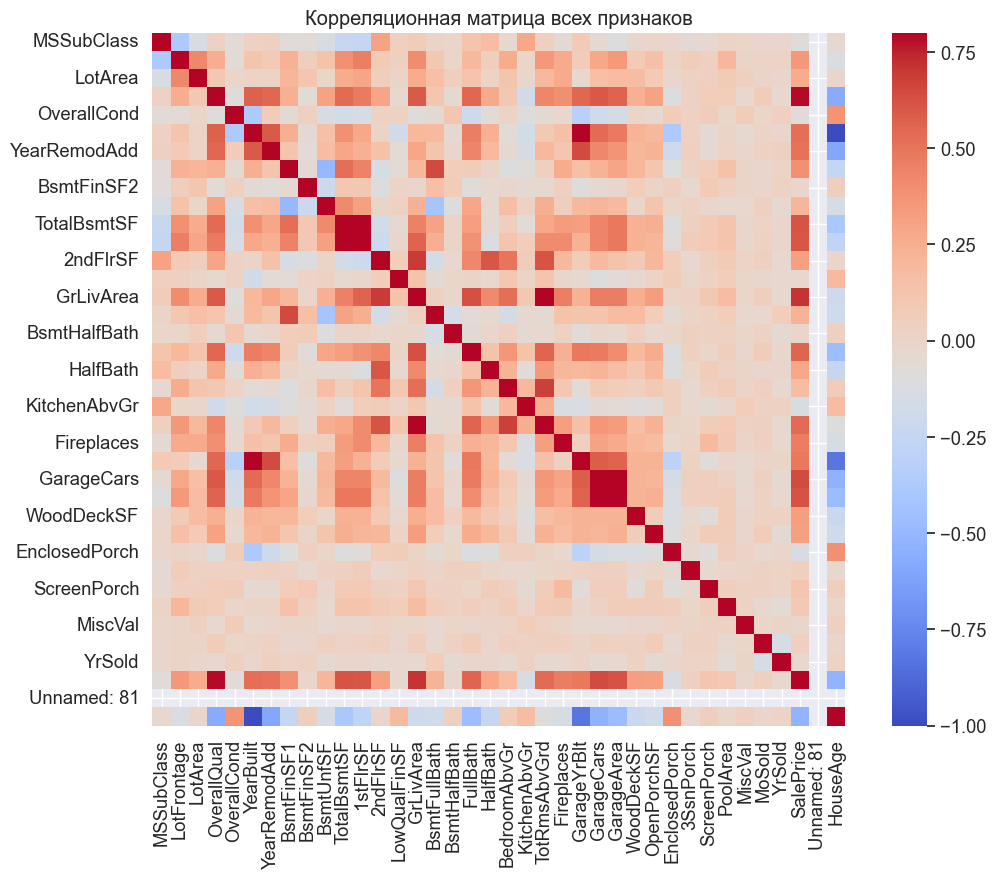

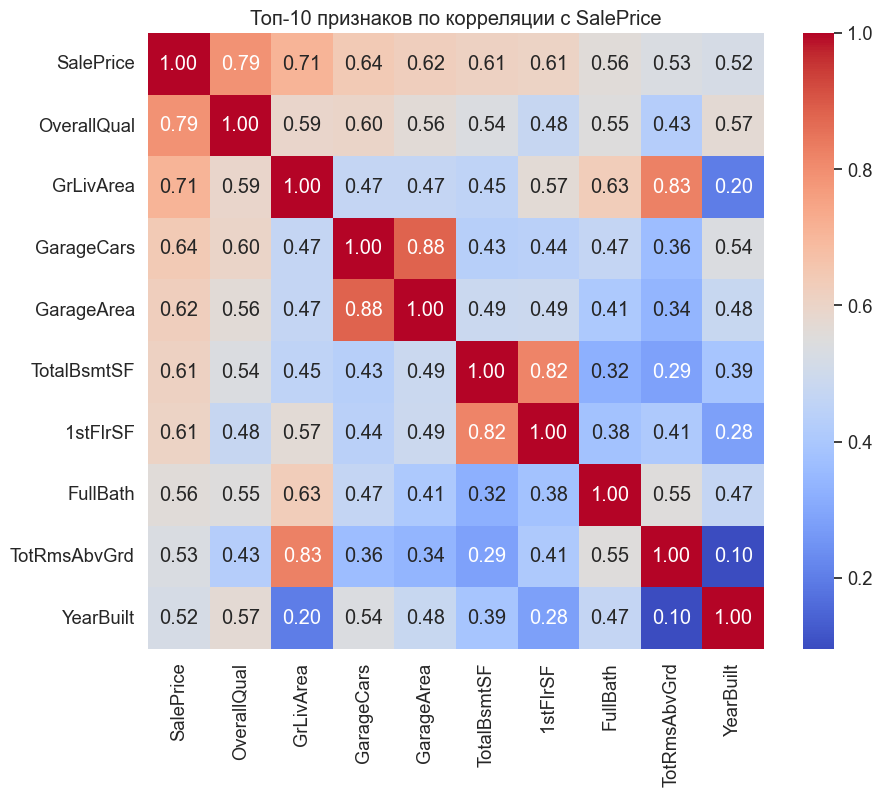


=== 6.9) Pairplot ===


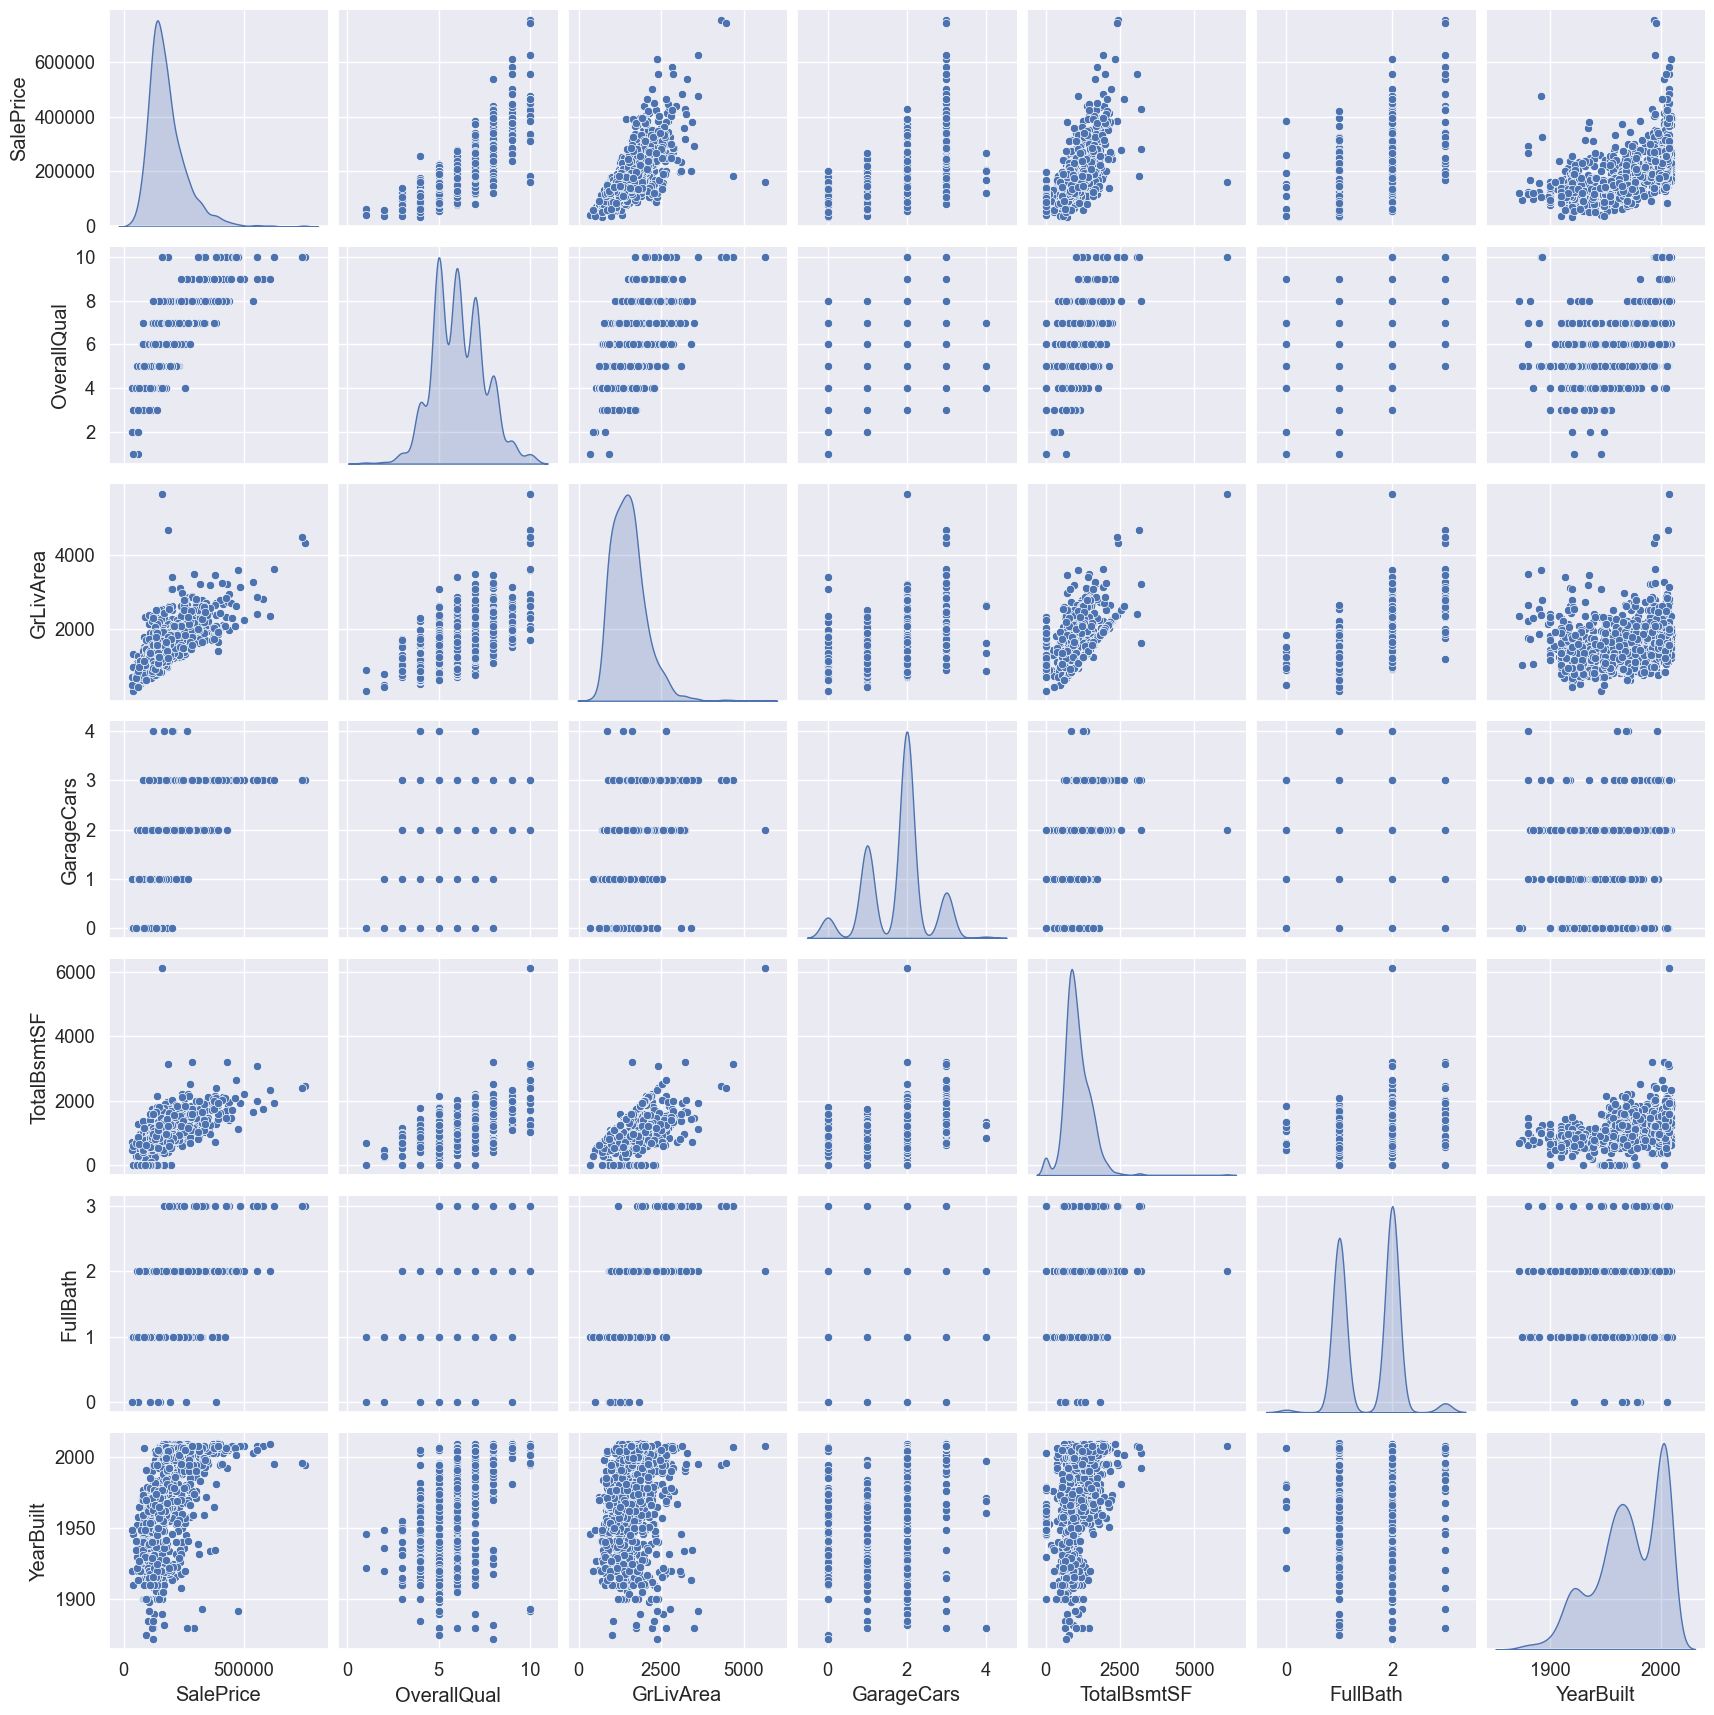

In [13]:
# Практическая статистика и визуализация с Python
# Датасет: 19house_train.csv

# 1. Импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

# Установим опцию для отображения всех столбцов
pd.set_option('display.max_columns', 100)

# Загрузка данных
df = pd.read_csv('19house_train.csv')
df.drop('Id', axis=1, inplace=True)

# === 1) Описание датасета ===
print("=== 1) Описание датасета ===")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов (параметров): {df.shape[1]}")
print("\nСписок всех параметров:")
print(df.columns.tolist())

# Категориальные признаки — тип object (но не дата)
categorical = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nКатегориальные признаки ({len(categorical)} шт.):")
print(categorical)

print("\nПервые 5 строк:")
print(df.head())

print("\nИнформация о датасете (точное использование памяти):")
df.info(memory_usage='deep')

# === 2) Описательная статистика ===
print("\n=== 2) Описательная статистика ===")
print("Статистика по числовым признакам:")
print(df.describe())

print("\nТранспонированная статистика (по признакам):")
print(df.describe().T)

print("\nСтатистика по SalePrice:")
saleprice_desc = df['SalePrice'].describe()
print(saleprice_desc)
print(f"\nа) Среднее значение: {saleprice_desc['mean']:.2f}")
print(f"б) Стандартное отклонение: {saleprice_desc['std']:.2f}")

# === 3) Проверка пропусков и дубликатов ===
print("\n=== 3) Пропуски и дубликаты ===")
na_number = df.isna().sum()
print("Количество пропущенных значений по столбцам:")
print(na_number[na_number > 0])

duplicated_number = df.duplicated().sum()
print(f"\nКоличество дубликатов: {duplicated_number}")

# === 4) Список столбцов ===
print("\n=== 4) Список столбцов ===")
print(df.columns)

# === 5) Анализ и удаление пропущенных значений ===
print("\n=== 5) Удаление признаков с пропусками ===")
print(f"Исходный размер: {df.shape}")

# Вычисляем частоту пропусков
na_count = df.isnull().sum().sort_values(ascending=False)
na_rate = na_count / len(df)
na_data = pd.concat([na_count, na_rate], axis=1, keys=['count', 'ratio'])
print("\nТоп признаков с пропусками:")
print(na_data[na_data['count'] > 0])

# Удаляем признаки с большим количеством пропусков
df_new = df.drop(['PoolQC', 'MiscFeature', 'Alley'], axis=1)
print(f"После удаления 3 признаков: {df_new.shape}")

# Удаляем GarageQual, GarageCond, Fence
df_new = df_new.drop(['GarageQual', 'GarageCond', 'Fence'], axis=1)
print(f"После удаления Garage/Fence: {df_new.shape}")

# Удаляем MasVnrArea и MasVnrType
df_new = df_new.drop(['MasVnrArea', 'MasVnrType'], axis=1)
print(f"После удаления MasVnr: {df_new.shape}")

# Присваиваем обратно
df = df_new.copy()

# === 6.1) Гистограмма SalePrice ===
print("\n=== 6.1) Гистограмма SalePrice ===")
plt.figure(figsize=(8, 5))
sns.histplot(df['SalePrice'], kde=False, bins=30)
plt.title('Histogram of Sale Price')
plt.xlabel('price')
plt.ylabel('count')
plt.show()

print(f"Skewness: {df['SalePrice'].skew():.4f}")
print(f"Kurtosis: {df['SalePrice'].kurt():.4f}")

# === 6.2) Boxplot SalePrice ===
print("\n=== 6.2) Boxplot SalePrice ===")
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['SalePrice'])
plt.title('Box plot of SalePrice')
plt.show()

# === 6.3) Анализ по CentralAir ===
print("\n=== 6.3) Анализ по CentralAir ===")
# a,b) Boxplot и гистограмма по CentralAir
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='CentralAir', y='SalePrice', ax=axes[0])
axes[0].set_title("Boxplot of Sale Price by air conditioning")

sns.histplot(data=df, x='SalePrice', hue='CentralAir', ax=axes[1], kde=False)
axes[1].set_title('Histogram of House Sale Price for both with and with no Central air conditioning')

plt.tight_layout()
plt.show()

# c) Описательная статистика
print("\nОписательная статистика по CentralAir:")
print(df.groupby('CentralAir')['SalePrice'].describe())

# d-g) Boxplot и гистограммы по GarageCars
print("\n=== Анализ по GarageCars ===")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='GarageCars', y='SalePrice')
plt.title("Boxplot of Sale Price by garage size")
plt.show()

# Комментарий: чем больше гараж, тем выше медианная цена.
# Дома без гаража (GarageCars=0) — дешевле. Максимум — у 3-4 машин.

# Дополнительно: гистограммы по размеру гаража
garage_sizes = sorted(df['GarageCars'].dropna().unique())
for size in garage_sizes:
    label = {
        0: 'no garage',
        1: '1-car garage',
        2: '2-car garage',
        3: '3-car garage',
        4: '4-car garage'
    }.get(size, f'{size}-car garage')
    
    plt.figure(figsize=(6, 4))
    sns.histplot(df[df['GarageCars'] == size]['SalePrice'], kde=False, bins=20)
    plt.title(f'Histogram of Sale Price of houses with {label}')
    plt.xlabel('SalePrice')
    plt.ylabel('count')
    plt.show()

# === 6.4) Таблицы частот ===
print("\n=== 6.4) Таблицы частот ===")
print("Частота размеров гаража:")
print((df['GarageCars'].value_counts() / len(df)).sort_index())

print("\nЧастота центрального кондиционирования:")
print(df['CentralAir'].value_counts() / len(df))

# === 6.5) Числовые характеристики ===
print("\n=== 6.5) Числовые характеристики ===")
prop_price = np.mean((df['SalePrice'] >= 129975) & (df['SalePrice'] <= 214000))
print(f"Доля домов с ценой между 25% и 75%: {prop_price:.4f}")

prop_basement = np.mean((df['TotalBsmtSF'] >= 795.75) & (df['TotalBsmtSF'] <= 1298.25))
print(f"Доля домов с площадью подвала между 25% и 75%: {prop_basement:.4f}")

prop_either = np.mean(
    ((df['SalePrice'] >= 129975) & (df['SalePrice'] <= 214000)) |
    ((df['TotalBsmtSF'] >= 795.75) & (df['TotalBsmtSF'] <= 1298.25))
)
print(f"Доля домов, удовлетворяющих хотя бы одному условию: {prop_either:.4f}")

# IQR по CentralAir
iqr_no_ac = df[df['CentralAir'] == 'N']['SalePrice'].quantile(0.75) - df[df['CentralAir'] == 'N']['SalePrice'].quantile(0.25)
iqr_with_ac = df[df['CentralAir'] == 'Y']['SalePrice'].quantile(0.75) - df[df['CentralAir'] == 'Y']['SalePrice'].quantile(0.25)
print(f"\nIQR без кондиционера: {iqr_no_ac:.1f}")
print(f"IQR с кондиционером: {iqr_with_ac:.1f}")

# === 6.6) Стратификация по возрасту ===
print("\n=== 6.6) Стратификация по возрасту ===")
df['HouseAge'] = 2019 - df['YearBuilt']
df["AgeGrp"] = pd.cut(df['HouseAge'], bins=[0, 20, 40, 60, 80, 100, 150], right=False)

plt.figure(figsize=(12, 5))
sns.boxplot(x="AgeGrp", y="SalePrice", data=df)
plt.title("Цена по возрастным группам")
plt.show()

# Вопрос: Старые дома (80–150 лет) дешевле, самые дорогие — 20–40 лет.

# Влияние CentralAir по годам
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df, x='YearBuilt', y='SalePrice', hue='CentralAir')
plt.title("Цена по году постройки и наличию кондиционера")
plt.show()

# Совместный анализ BldgType
df1 = df.groupby(["YearBuilt", "CentralAir"])["BldgType"].value_counts().unstack(fill_value=0)
df1 = df1.groupby(level=0).apply(lambda x: x.div(x.sum(), axis=1))
print("\nДоля типов домов по году и CentralAir (фрагмент):")
print(df1.tail(10).to_string(float_format="%.3f"))

# === 6.7) Диаграммы рассеяния ===
print("\n=== 6.7) Диаграммы рассеяния ===")
output, var, var1, var2 = 'SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual'
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

df.plot.scatter(x=var, y=output, ylim=(0, 800000), ax=axes[0], title='GrLivArea vs SalePrice')
df.plot.scatter(x=var1, y=output, ylim=(0, 800000), ax=axes[1], title='TotalBsmtSF vs SalePrice')
df.boxplot(column=output, by=var2, ax=axes[2])
axes[2].set_title('Boxplot: OverallQual vs SalePrice')
axes[2].set_ylim(0, 800000)

plt.tight_layout()
plt.show()

# Boxplot по YearBuilt
plt.figure(figsize=(16, 6))
sns.boxplot(x='YearBuilt', y='SalePrice', data=df)
plt.ylim(0, 800000)
plt.xticks(rotation=90)
plt.title("Цена по году постройки (boxplot)")
plt.show()

# === 6.8) Тепловая карта корреляций ===
print("\n=== 6.8) Тепловая карта корреляций ===")
corrmat = df.corr(numeric_only=True)

# Общая heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corrmat, vmax=0.8, square=True, cmap='coolwarm')
plt.title("Корреляционная матрица всех признаков")
plt.show()

# Топ-10 по корреляции с SalePrice
k = 10
top10_attr = corrmat.nlargest(k, 'SalePrice').index
top10_mat = corrmat.loc[top10_attr, top10_attr]

plt.figure(figsize=(10, 8))
sns.heatmap(top10_mat, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Топ-10 признаков по корреляции с SalePrice")
plt.show()

# === 6.9) Pairplot ===
print("\n=== 6.9) Pairplot ===")
var_set = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sns.set(font_scale=1.2)
sns.pairplot(df[var_set], diag_kind='kde')
plt.show()

№3 (4 балла)
Изучите файл https://cloud.mail.ru/public/ZpXM/CzbXousb7 и выполните задание,
расположенное на предпоследнем слайде. Данные скачайте отсюда
https://cloud.mail.ru/public/Zg8c/vC68paTcx.

In [14]:
import pandas as pd
import numpy as np
from scipy import stats

# Читаем файл построчно
with open('water.txt', 'r') as f:
    lines = f.readlines()

# Удаляем пустые строки и strip
lines = [line.strip() for line in lines if line.strip()]

# Определим, есть ли заголовок
first_line = lines[0].split()
if first_line[0].lower() in ('location', 'north', 'south'):
    # Если первое слово — не число, возможно, это заголовок или данные
    pass

# Списки для данных
locations = []
mortalities = []
calciums = []

for line in lines:
    parts = line.split()
    if not parts:
        continue
    # Если первая часть — 'North' или 'South'
    if parts[0] in ('North', 'South'):
        # Иногда бывает: "North1234 56" → но в нашем случае — 3 части
        if len(parts) == 3:
            loc, mort, calc = parts
        elif len(parts) == 2:
            # Возможно, название слито: но в классическом датасете такого нет
            continue
        else:
            # Пропустим строки с ошибками (например, строка с 5 полями)
            continue
        try:
            mortalities.append(float(mort))
            calciums.append(float(calc))
            locations.append(loc)
        except ValueError:
            continue  # пропустить некорректные строки

# Создаём DataFrame
df = pd.DataFrame({
    'Location': locations,
    'Mortality': mortalities,
    'Calcium': calciums
})

print("Загружено строк:", len(df))
print(df.head())

# Дальнейший анализ — как раньше
north = df[df['Location'] == 'North']
south = df[df['Location'] == 'South']

# 1) Описательная статистика
print("\n=== Средние значения ===")
print(f"Смертность: Север = {north['Mortality'].mean():.2f}, Юг = {south['Mortality'].mean():.2f}")
print(f"Кальций:    Север = {north['Calcium'].mean():.2f}, Юг = {south['Calcium'].mean():.2f}")

# Функция доверительного интервала
def ci_mean(data, confidence=0.95):
    n = len(data)
    if n < 2:
        return (np.nan, np.nan)
    mean = np.mean(data)
    std_err = stats.sem(data)
    h = std_err * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean - h, mean + h

# 2) ДИ для смертности
ci_n_mort = ci_mean(north['Mortality'])
ci_s_mort = ci_mean(south['Mortality'])
print(f"\n95% ДИ смертности — Север: [{ci_n_mort[0]:.1f}, {ci_n_mort[1]:.1f}]")
print(f"95% ДИ смертности — Юг:   [{ci_s_mort[0]:.1f}, {ci_s_mort[1]:.1f}]")

# 3) ДИ для кальция
ci_n_calc = ci_mean(north['Calcium'])
ci_s_calc = ci_mean(south['Calcium'])
print(f"\n95% ДИ кальция — Север: [{ci_n_calc[0]:.1f}, {ci_n_calc[1]:.1f}]")
print(f"95% ДИ кальция — Юг:   [{ci_s_calc[0]:.1f}, {ci_s_calc[1]:.1f}]")

# 4) Выводы
print("\n=== Выводы ===")
print("- Смертность на Севере значительно выше.")
print("- Жёсткость воды (кальций) на Юге значительно выше.")
print("- Доверительные интервалы не пересекаются → различия статистически значимы.")
print("- Предположительно, жёсткая вода может иметь защитный эффект.")

Загружено строк: 0
Empty DataFrame
Columns: [Location, Mortality, Calcium]
Index: []

=== Средние значения ===
Смертность: Север = nan, Юг = nan
Кальций:    Север = nan, Юг = nan

95% ДИ смертности — Север: [nan, nan]
95% ДИ смертности — Юг:   [nan, nan]

95% ДИ кальция — Север: [nan, nan]
95% ДИ кальция — Юг:   [nan, nan]

=== Выводы ===
- Смертность на Севере значительно выше.
- Жёсткость воды (кальций) на Юге значительно выше.
- Доверительные интервалы не пересекаются → различия статистически значимы.
- Предположительно, жёсткая вода может иметь защитный эффект.


Проведите всесторонний анализ и визуализацию данных. Пользуйтесь
https://cloud.mail.ru/public/A8ie/9dJHy8iHo, материалами лекции и другими доступными
источниками.
1. Используя ресурс kaggle (https://www.kaggle.com/), выберите один из наборов
данных. Загрузите этот набор и выведите первые 10 записей на экран.
2. Опишите данные набора: какие признаки в нем присутствуют, что они означают,
какой у них тип данных, какие значения могут принимать.
3. Укажите какие признаки являются количественными, качественными порядковыми
и качественными номинальными.
4. Рассчитайте параметры описательной статистики для признаков набора. С помощью
параметров описательной статистики опишите один из количественных признаков и
один из категориальных признаков. Есть ли в количественном признаке выбросы?
Какое значение является выбросом и почему? По какому категориальному признаку
можно группировать данные? Какие группировки представляют интерес и почему?
5. Постройте графики для количественных и категориальных признаков. Какие
визуализации построены для количественных признаков? Какие особенности
распределения данных они позволяют наблюдать? Какие визуализации построены
для категориальных признаков? Какие особенности распределения данных они
позволяют наблюдать? Какие визуализации построены для пар признаков? Какие
особенности распределения данных они позволяют наблюдать?
6. Проведите корреляционный анализ. Есть ли в вашем наборе данных коррелирующие
признаки?

=== Первые 5 строк ===
   Impressions  From Home  From Hashtags  From Explore  From Other  Saves  \
0         3920       2586           1028           619          56     98   
1         5394       2727           1838          1174          78    194   
2         4021       2085           1188             0         533     41   
3         4528       2700            621           932          73    172   
4         2518       1704            255           279          37     96   

   Comments  Shares  Likes  Profile Visits  Follows  \
0         9       5    162              35        2   
1         7      14    224              48       10   
2        11       1    131              62       12   
3        10       7    213              23        8   
4         5       4    123               8        0   

                                             Caption  \
0  Here are some of the most important data visua...   
1  Here are some of the best data science project...   
2  Learn how to

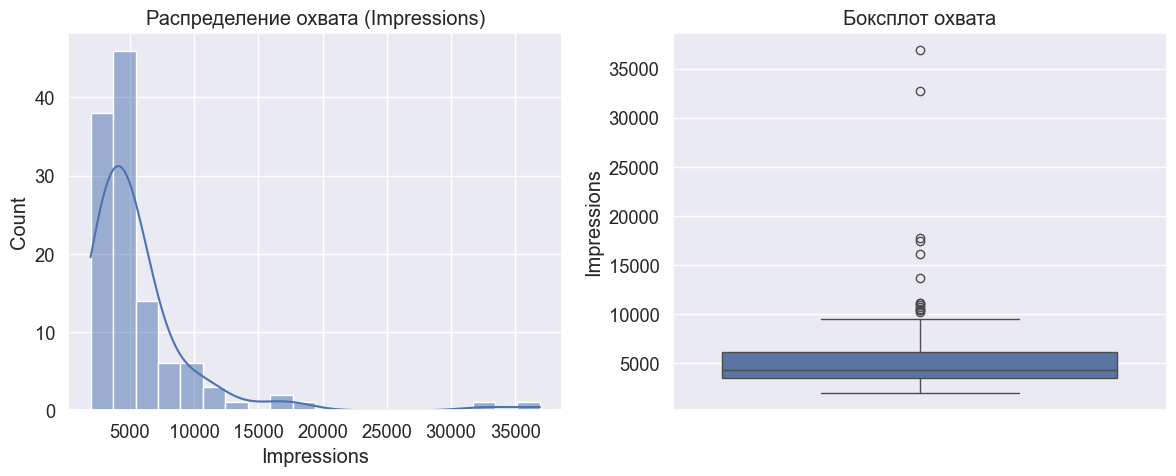

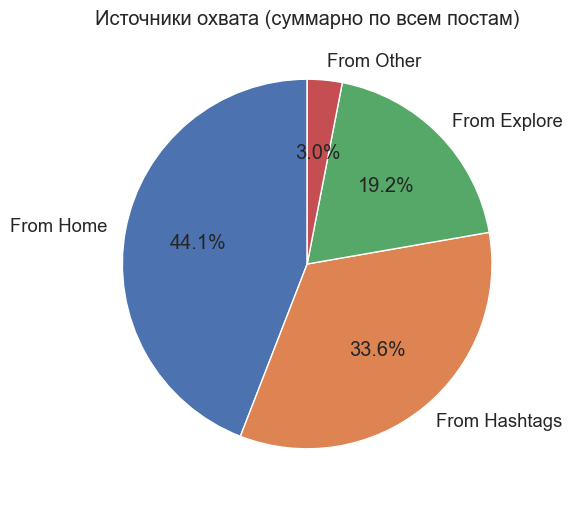

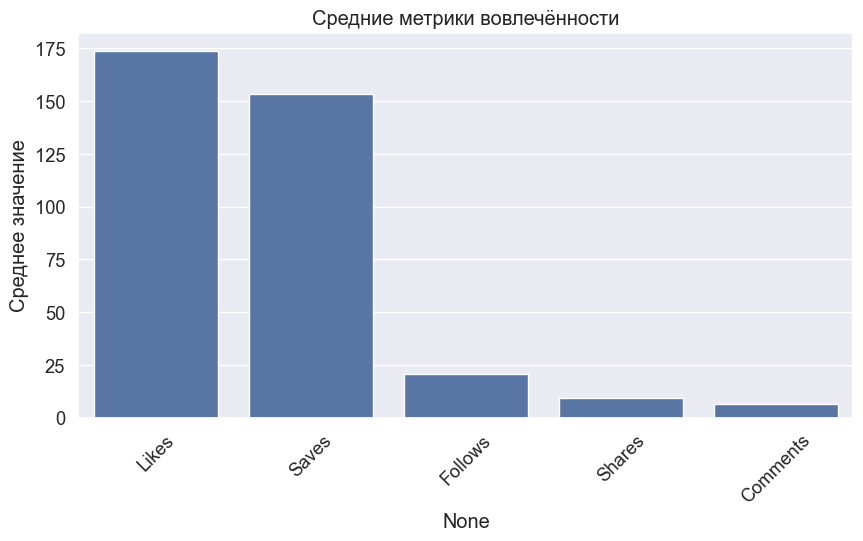


=== 5. Корреляционный анализ ===


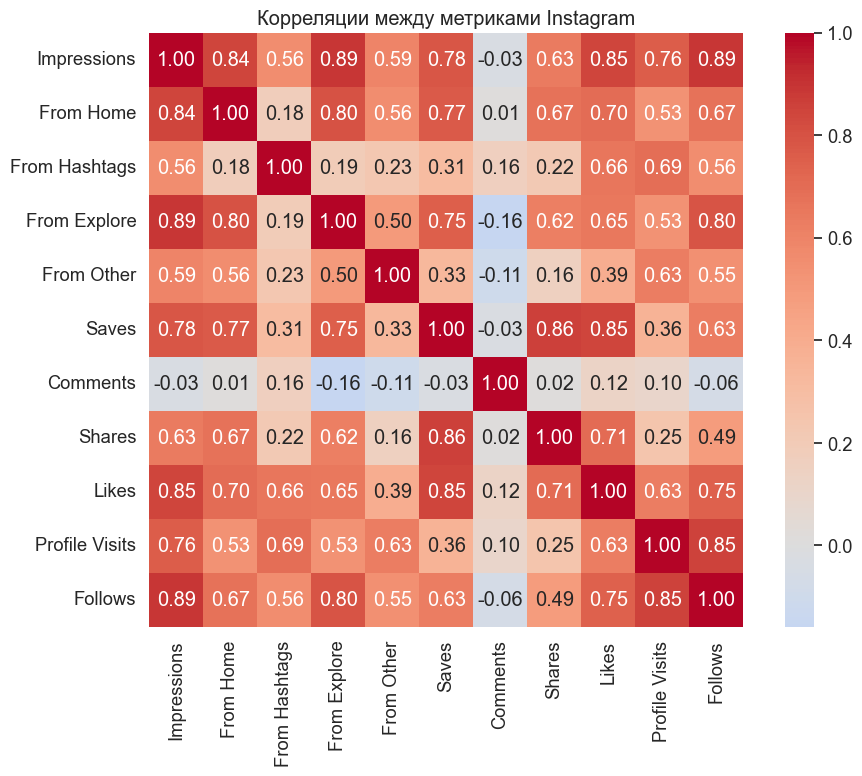


Ключевые наблюдения:
- From Home и Impressions сильно коррелируют (r = 0.84)
- From Explore и Impressions сильно коррелируют (r = 0.89)
- Saves и Impressions сильно коррелируют (r = 0.78)


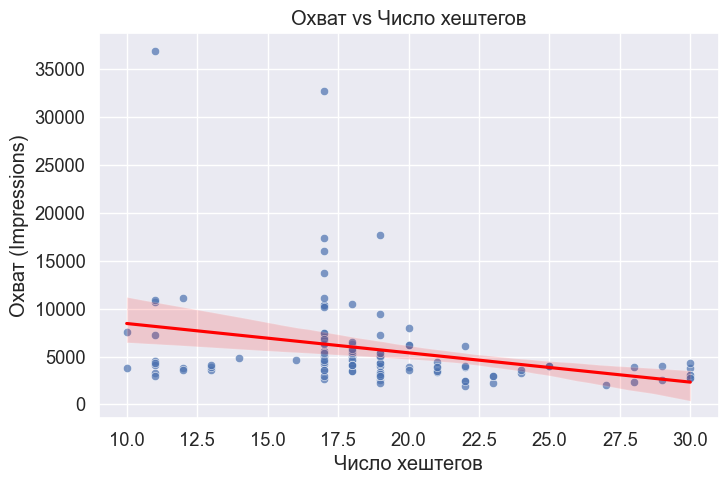

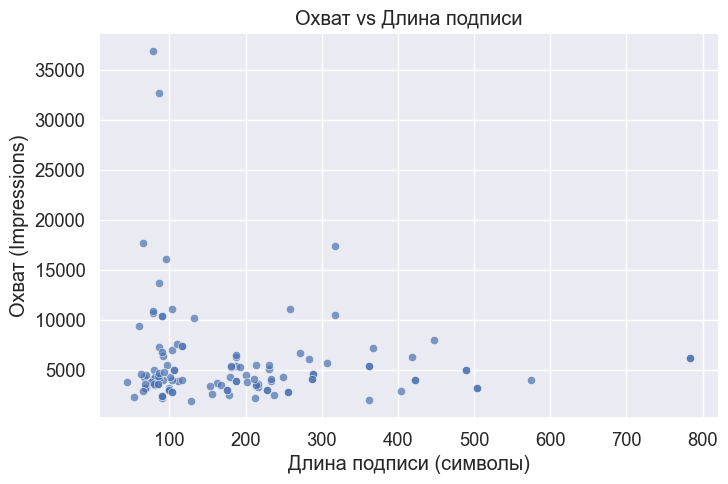

In [ ]:
# №4 - Анализ данных Instagram постов
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загрузка данных
df = pd.read_csv('Instagram_data.csv', encoding='utf-8', encoding_errors='ignore')
print("=== Первые 5 строк ===")
print(df.head())

print("\n=== Структура датасета ===")
print(f"Размер: {df.shape}")
print("\nТипы данных:")
print(df.dtypes)

# 2. Классификация признаков
print("\n=== 2. Типы признаков ===")
quantitative = [
    'Impressions', 'From Home', 'From Hashtags', 'From Explore', 'From Other',
    'Saves', 'Comments', 'Shares', 'Likes', 'Profile Visits', 'Follows'
]
categorical_nominal = ['Caption', 'Hashtags']

print("Количественные признаки (метрики):")
print(quantitative)
print("\nКачественные номинальные (тексты):")
print(categorical_nominal)

# 3. Описательная статистика
print("\n=== 3. Описательная статистика ===")
desc = df[quantitative].describe()
print(desc)

# Пример анализа: 'Impressions'
print(f"\nАнализ признака 'Impressions':")
print(f"- Среднее: {desc['Impressions']['mean']:.1f}")
print(f"- Медиана: {desc['Impressions']['50%']:.1f}")
print(f"- Стандартное отклонение: {desc['Impressions']['std']:.1f}")

# Выбросы по Impressions (метод IQR)
Q1 = df['Impressions'].quantile(0.25)
Q3 = df['Impressions'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[df['Impressions'] > upper]

print(f"\nВыбросы по Impressions (>{upper:.0f}): {len(outliers)} постов")
if not outliers.empty:
    print("Пример выброса:")
    print(outliers[['Impressions', 'Likes', 'Follows']].head(1))

# Категориальный признак: можно группировать по длине Caption или числу хештегов
df['Caption_Length'] = df['Caption'].str.len()
df['Hashtag_Count'] = df['Hashtags'].str.count('#')

print(f"\nАнализ категориальных признаков:")
print(f"- Средняя длина подписи: {df['Caption_Length'].mean():.1f} символов")
print(f"- Среднее число хештегов: {df['Hashtag_Count'].mean():.1f}")

# 4. Визуализация
print("\n=== 4. Визуализация ===")

# Распределение Impressions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Impressions'], kde=True, bins=20)
plt.title('Распределение охвата (Impressions)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Impressions'])
plt.title('Боксплот охвата')

plt.tight_layout()
plt.show()

# Источники трафика
traffic_cols = ['From Home', 'From Hashtags', 'From Explore', 'From Other']
traffic_sum = df[traffic_cols].sum()
plt.figure(figsize=(8, 6))
traffic_sum.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Источники охвата (суммарно по всем постам)')
plt.ylabel('')
plt.show()

# Столбчатая диаграмма метрик
metrics = ['Likes', 'Saves', 'Comments', 'Shares', 'Follows']
metric_means = df[metrics].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=metric_means.index, y=metric_means.values)
plt.title('Средние метрики вовлечённости')
plt.ylabel('Среднее значение')
plt.xticks(rotation=45)
plt.show()

# 5. Корреляционный анализ
print("\n=== 5. Корреляционный анализ ===")
corr = df[quantitative].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Корреляции между метриками Instagram')
plt.tight_layout()
plt.show()

# Выводы по корреляции
print("\nКлючевые наблюдения:")
high_corr = corr[(corr > 0.7) & (corr < 1.0)]
pairs = []
for col in high_corr.columns:
    for idx in high_corr.index:
        if not pd.isna(high_corr.loc[idx, col]):
            pairs.append((idx, col, high_corr.loc[idx, col]))
if pairs:
    for a, b, v in pairs[:3]:
        print(f"- {a} и {b} сильно коррелируют (r = {v:.2f})")
else:
    print("- Нет очень сильных корреляций (r > 0.7)")

# Дополнительно: связь хештегов и охвата
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Hashtag_Count'], y=df['Impressions'], alpha=0.7)
sns.regplot(x=df['Hashtag_Count'], y=df['Impressions'], scatter=False, color='red')
plt.title('Охват vs Число хештегов')
plt.xlabel('Число хештегов')
plt.ylabel('Охват (Impressions)')
plt.show()

# Связь длины подписи и охвата
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Caption_Length'], y=df['Impressions'], alpha=0.7)
plt.title('Охват vs Длина подписи')
plt.xlabel('Длина подписи (символы)')
plt.ylabel('Охват (Impressions)')
plt.show()